In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path = '../data/txt/'

In [5]:
tmp = pd.read_csv(path+'full_temperature_timeSerie_CH_prep.txt',delimiter = '\t')

In [7]:
tmp.head()

,time,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec,djf,mam,jja,son,winter,summer,year
0,1864,-7.10,-4.52,0.04,2.11,7.43,9.48,12.37,10.95,8.59,3.50,-0.51,-4.47,NaN,3.19,10.93,3.86,NaN,8.49,3.16
1,1865,-3.47,-6.25,-5.91,7.03,10.09,10.98,13.99,11.16,11.90,5.19,1.26,-3.07,-4.73,3.74,12.04,6.12,-2.85,10.86,4.41
2,1866,-1.31,-0.42,-1.00,4.11,4.95,12.02,12.25,9.98,9.70,5.34,-0.20,-0.49,-1.60,2.69,11.42,4.95,0.11,8.84,4.58
3,1867,-3.87,0.56,-0.13,3.49,7.74,10.57,11.29,12.93,10.43,2.92,-1.43,-5.80,-1.27,3.70,11.60,3.97,0.20,9.41,4.06
4,1868,-5.46,-1.53,-2.30,2.33,12.04,11.97,12.89,12.50,11.12,4.76,-1.98,1.27,-4.26,4.02,12.45,4.63,-2.27,10.47,4.80


In [135]:
tmp.columns

Index(['time', 'jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep',
       'oct', 'nov', 'dec', 'djf', 'mam', 'jja', 'son', 'winter', 'summer',
       'year'],
      dtype='object')

In [139]:
tmp_mean = tmp[['time','year']].copy()
tmp_mean.to_csv('meanCH_temp.csv')

In [53]:
prc = pd.read_csv(path+'full_valais_precipitation_CH_prep.txt',delimiter=',')
#prc.iloc[:,3][prc.iloc[:,3]=='nan  '] = np.nan

In [54]:
prc = prc.dropna()
prc.head()

,Year,Month,Temperature,Precipitation
3,1864,4,9.5,13.3
4,1864,5,14.5,67.9
5,1864,6,15.6,92.5
6,1864,7,18.6,35.6
7,1864,8,17.0,31.7


In [72]:
prc_mean = prc.groupby('Year').mean()
prc_mean.head()

,Month,Temperature,Precipitation
Year,,,
1864,8.0,10.688889,38.633333
1865,6.5,9.158333,36.316667
1866,6.5,9.033333,68.383333
1867,6.5,8.600000,60.250000
1868,6.5,9.166667,45.441667


In [97]:
prc_2 = pd.read_csv(path+'full_chateauDoex_precipitation_CH_prep.txt',delimiter=',')

In [100]:
prc_2 = prc_2.dropna()
prc_2.head()

,Year,Month,Temperature,Precipitation
0,1879,1,-5.4,73.0
1,1879,2,-3.3,115.0
2,1879,3,0.4,25.6
3,1879,4,2.7,103.2
4,1879,5,5.3,96.2


In [101]:
prc_mean_2 = prc_2.groupby('Year').mean()
prc_mean_2.head()

,Month,Temperature,Precipitation
Year,,,
1879,6.5,3.283333,103.225000
1880,6.5,5.058333,93.041667
1881,6.5,4.500000,103.050000
1882,6.5,4.866667,122.041667
1883,6.5,4.108333,95.716667


In [123]:
prc_mean_2.to_csv('chateauDoex.csv')

In [106]:
prc_mean_2.index[1]

1880

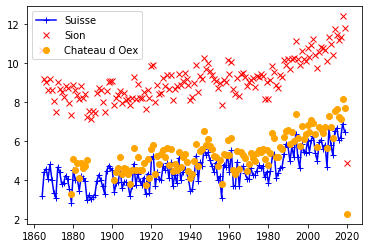

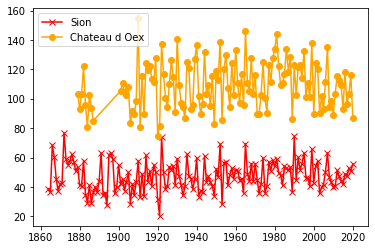

In [121]:
plt.plot(tmp.time, tmp.year, '+-b', label='Suisse')
plt.plot(prc.Year.unique(), prc_mean.Temperature,'xr', label='Sion')
plt.plot(prc_mean_2.index, prc_mean_2.Temperature,'o',color='orange', label='Chateau d Oex')
plt.legend()
plt.show()
plt.plot(prc.Year.unique(), prc_mean.Precipitation,'x-r', label='Sion')
plt.plot(prc_mean_2.index, prc_mean_2.Precipitation,'o-',color='orange', label='Chateau d Oex')
plt.legend()
plt.show()